# uxplain — Demo

A unified walkthrough for **regression** and **classification**.

**What this notebook covers**
- Conformal prediction intervals / sets with coverage guarantees
- XAI explanations: SHAP, PDP (+ ICE), LIME — using each library's native plots
- Multiple uncertainty metrics (`width`, `lower`, `upper`, `midpoint`)
- Multiple conformal methods (`standard`, `normalized`, `mondrian`, CQR)
- Conformal output summaries (set size, p-values)

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split

import uxplain as ue
from uxplain import (
    UncertaintyExplanationPipeline,
    ConformalMethod,
    ClassificationConformalMethod,
    CQRConformalPredictor,
)
from uxplain.plots import (
    generate_shap_plots,
    generate_pdp_plots,
    generate_lime_plots,
)

print(f"uxplain {ue.__version__}")


uxplain 0.2.0


/Users/torodriguezt/Documents/Tomas/GitHub/Uncertainty-Explainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Part 1 — Regression

Conformal prediction intervals for a regression model, explained with SHAP, PDP, and LIME.

### 1.1 Data

We use a synthetic dataset with 6 features (4 informative) and 1 000 samples.
Feature names are carried through automatically when `X` is a **DataFrame**.

In [2]:
np.random.seed(42)

X_raw, y = make_regression(
    n_samples=1000, n_features=6, n_informative=4, noise=25.0, random_state=42
)
feature_names = [
    "area_m2", "n_rooms", "age_years",
    "distance_to_center_km", "crime_rate", "school_rating",
]
X = pd.DataFrame(X_raw, columns=feature_names)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape} | Calib: {X_calib.shape} | Test: {X_test.shape}")

Train: (600, 6) | Calib: (200, 6) | Test: (200, 6)


### 1.2 Quickstart (3 lines)

Just a model — everything else uses sensible defaults.
`fit()` automatically splits 20 % of training data for calibration.

In [3]:
quick = UncertaintyExplanationPipeline(model=RandomForestRegressor(random_state=42))
quick.fit(X_train, y_train)
result = quick.explain(X_test.iloc[:20], show_plots=False)

covered = (result.lower <= y_test[:20]) & (y_test[:20] <= result.upper)
print(f"Coverage @ 90 %: {covered.mean():.2f}  (target ≥ 0.90)")
print(f"Mean interval width: {result.interval_width.mean():.2f}")

Coverage @ 90 %: 0.95  (target ≥ 0.90)
Mean interval width: 110.12


### 1.3 SHAP Explanations

SHAP attributes each feature's contribution to the **interval width**.

**`conformal_method` options** (regression):

| Value | Description |
|---|---|
| `"normalized"` | difficulty-scaled residuals *(default)* |
| `"standard"` | flat residuals |
| `"mondrian"` | residuals binned by a binned auxiliary variable |
| `"normalized_mondrian"` | both |
| `"cqr"` | Conformalized Quantile Regression |

In [4]:
pipeline_shap = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="shap",
)
pipeline_shap.fit(X_train, y_train, X_calib, y_calib)
result_shap = pipeline_shap.explain(X_test.iloc[:50], show_plots=False)

covered_shap = (result_shap.lower <= y_test[:50]) & (y_test[:50] <= result_shap.upper)
print(f"Coverage: {covered_shap.mean():.2f}")
print(f"SHAP values shape: {result_shap.explanation_values.values.shape}  (samples × features)")

Coverage: 0.94
SHAP values shape: (50, 6)  (samples × features)


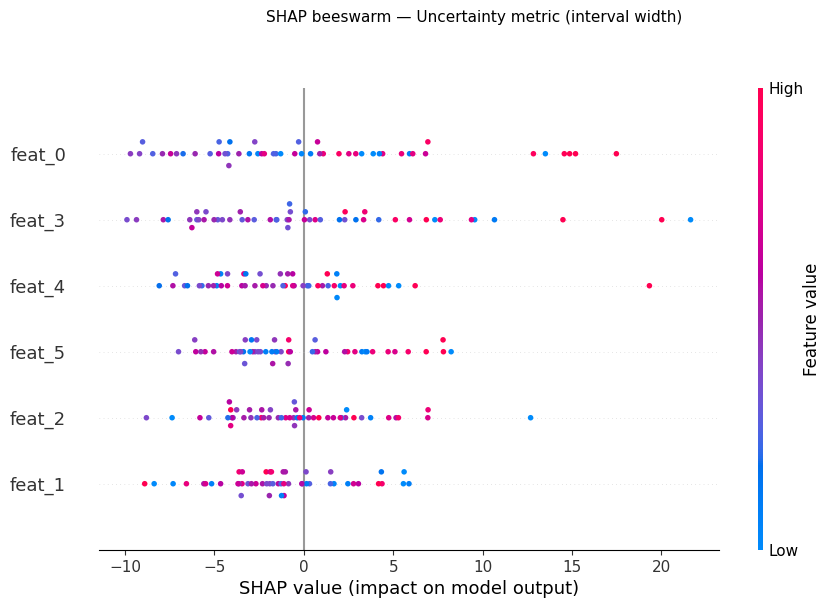

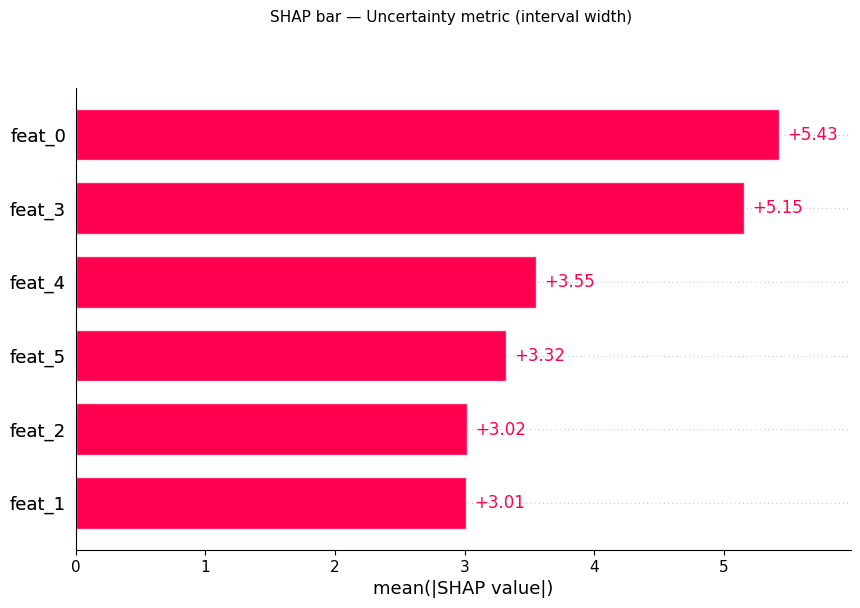

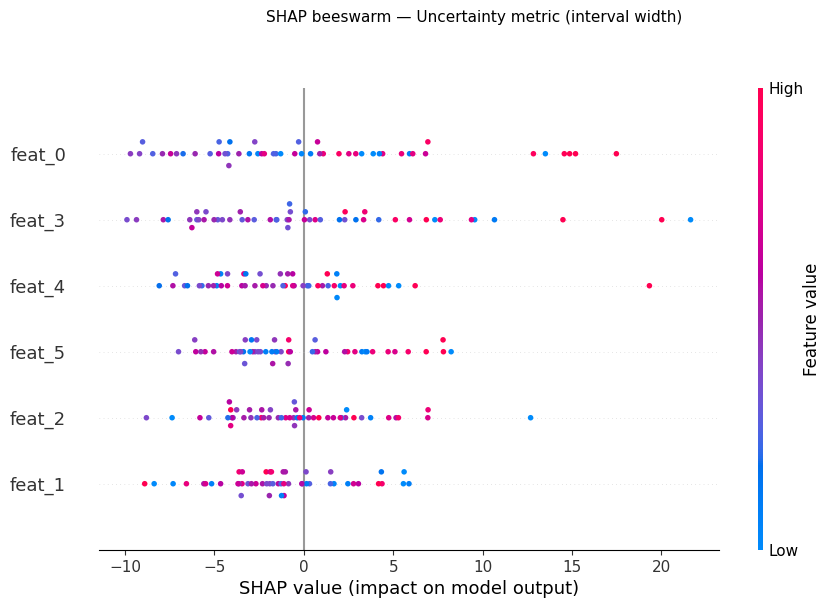

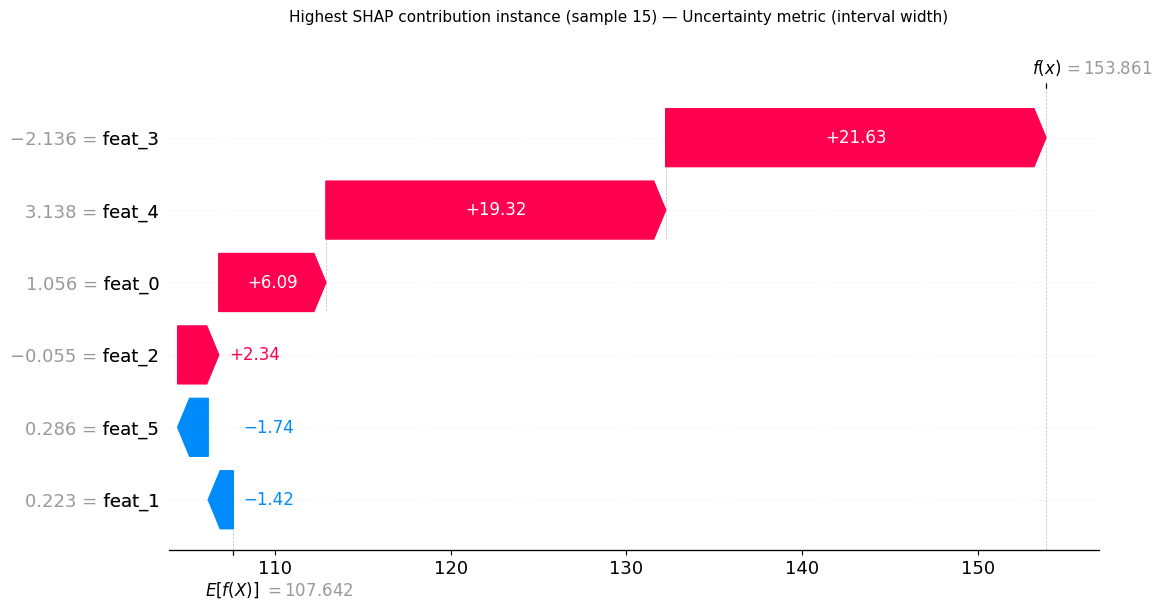

In [5]:
figs = generate_shap_plots(
    result_shap.explanation_values,
    X=X_test.iloc[:50],
    kinds=["beeswarm", "bar", "waterfall"],
    show=False,
)
figs["beeswarm"]

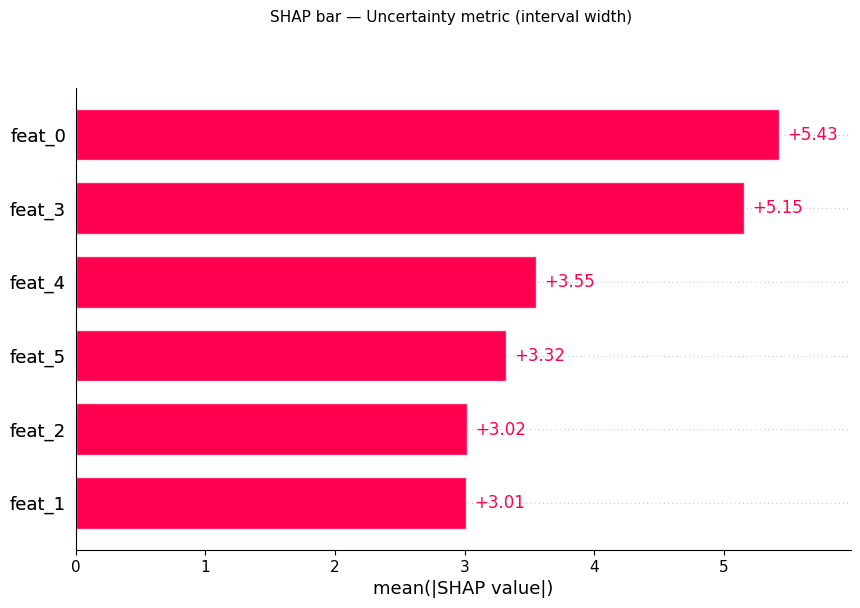

In [6]:
figs["bar"]

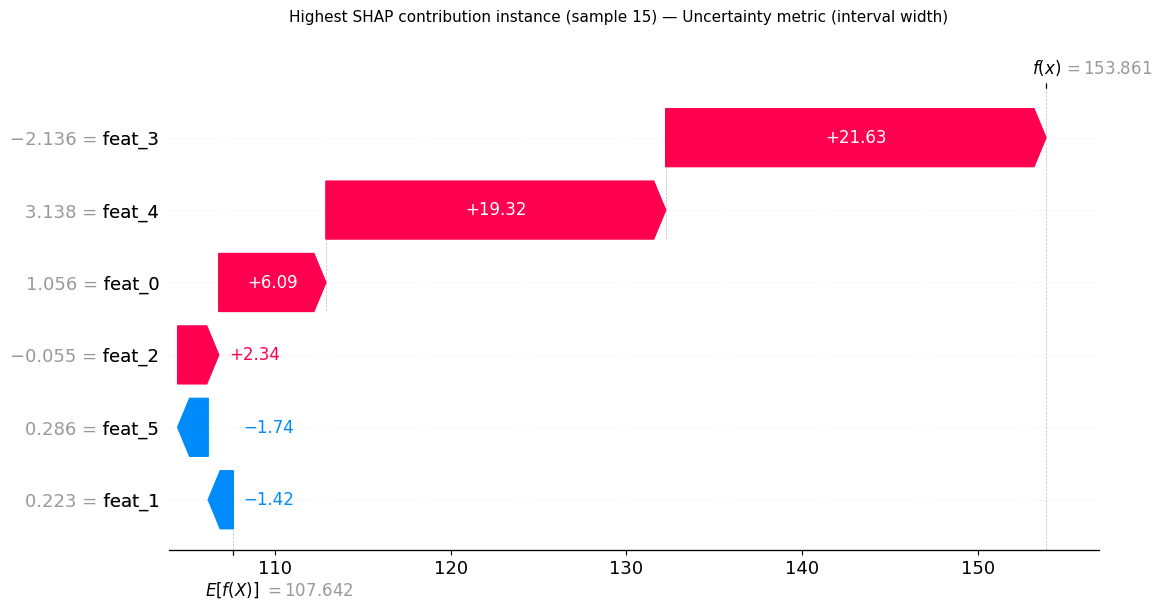

In [7]:
figs["waterfall"]

### 1.4 PDP + ICE Explanations

**Partial Dependence Plots** show the average effect of each feature on the uncertainty metric.
**ICE lines** (Individual Conditional Expectation) add per-sample curves.

Plots are rendered with **sklearn's native `PartialDependenceDisplay`**, including decile rug marks.

Use `kind="both"` so a single `explain()` call computes both.


In [8]:
pipeline_pdp = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="pdp",
)
pipeline_pdp.fit(X_train, y_train, X_calib, y_calib)

result_pdp = pipeline_pdp.explain(X_test.iloc[:100], kind="both", show_plots=False)

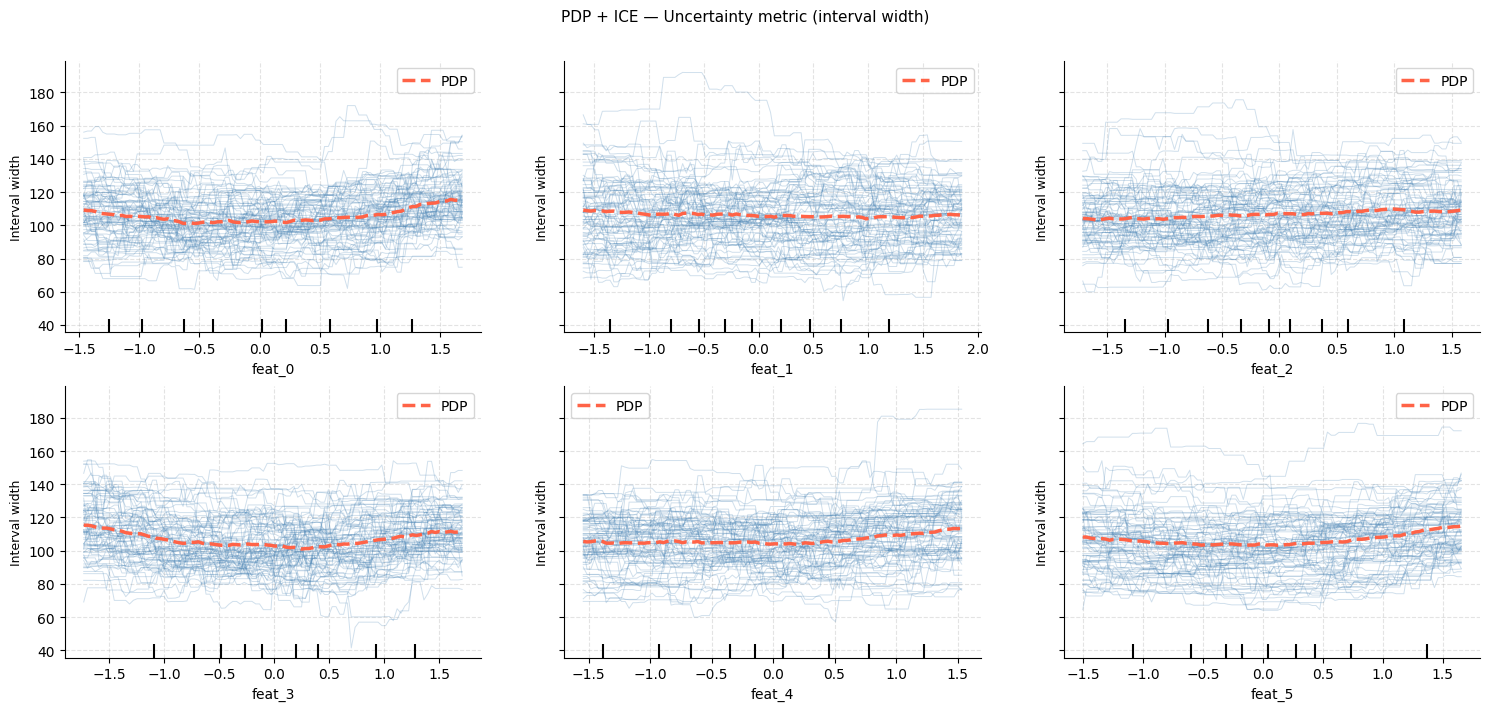

In [9]:
# PDP overlaid on ICE lines — tomato = average, steelblue = individual samples
figs_pdp = generate_pdp_plots(result_pdp.explanation_values, kinds=["pdp_ice"], show=False)
figs_pdp["pdp_ice"]

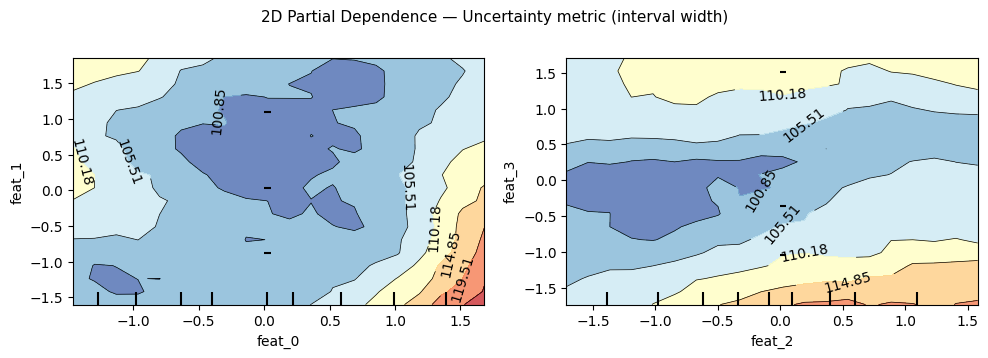

In [10]:
# 2D interaction heatmap — native sklearn PartialDependenceDisplay
result_2d = pipeline_pdp.explain(
    X_test.iloc[:100], features=[(0, 1), (2, 3)], show_plots=False
)
figs_2d = generate_pdp_plots(result_2d.explanation_values, kinds=["pdp_2d"], show=False)
figs_2d["pdp_2d"]


### 1.5 LIME Explanations

LIME fits a local linear model around each test point.

Plots use **LIME's native `as_pyplot_figure()`**, which shows the actual feature value ranges
that triggered each coefficient — more informative than a plain coefficient bar chart.

Positive coefficient → feature **increases** uncertainty.  
Negative coefficient → feature **decreases** uncertainty.


In [11]:
pipeline_lime = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="lime",
    n_lime_samples=300,
)
pipeline_lime.fit(X_train, y_train, X_calib, y_calib)
result_lime = pipeline_lime.explain(X_test.iloc[:5], show_plots=False)

print(f"Local coefficients shape: {result_lime.explanation_values.local_coefficients.shape}")

Local coefficients shape: (5, 6)


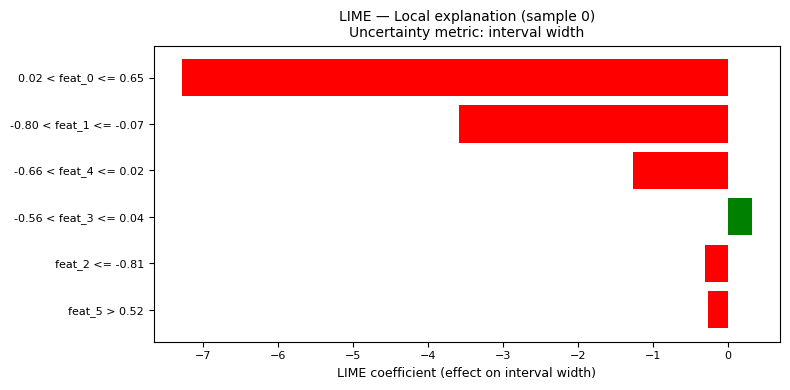

In [12]:
figs_lime = generate_lime_plots(
    result_lime.explanation_values, kinds=["local"], sample_index=0, show=False
)
figs_lime["local"]

### 1.6 Explaining Different Uncertainty Metrics

`uncertainty_metric` controls **what** SHAP/PDP/LIME explain:

| Value | Meaning |
|---|---|
| `"width"` | upper − lower *(default)* |
| `"lower"` | lower bound of the interval |
| `"upper"` | upper bound of the interval |
| `"midpoint"` | (lower + upper) / 2 — the point prediction |

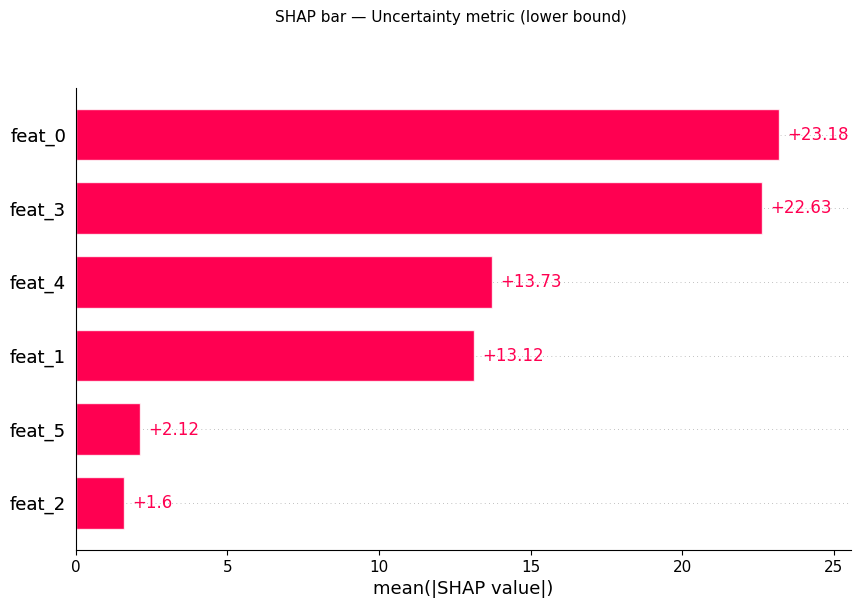

In [13]:
# What drives the LOWER bound?
pipeline_lower = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    xai_method="shap",
    uncertainty_metric="lower",
)
pipeline_lower.fit(X_train, y_train, X_calib, y_calib)
result_lower = pipeline_lower.explain(X_test.iloc[:50], show_plots=False)

figs_lower = generate_shap_plots(
    result_lower.explanation_values, X=X_test.iloc[:50], kinds=["bar"], show=False
)
figs_lower["bar"]

### 1.7 CQR — Conformalized Quantile Regression

CQR uses separate quantile regressors for the lower and upper bounds, then conforms them.
Ideal when the base model is a quantile regressor (e.g. `GradientBoostingRegressor`).

CQR Coverage @ 90 %: 0.92


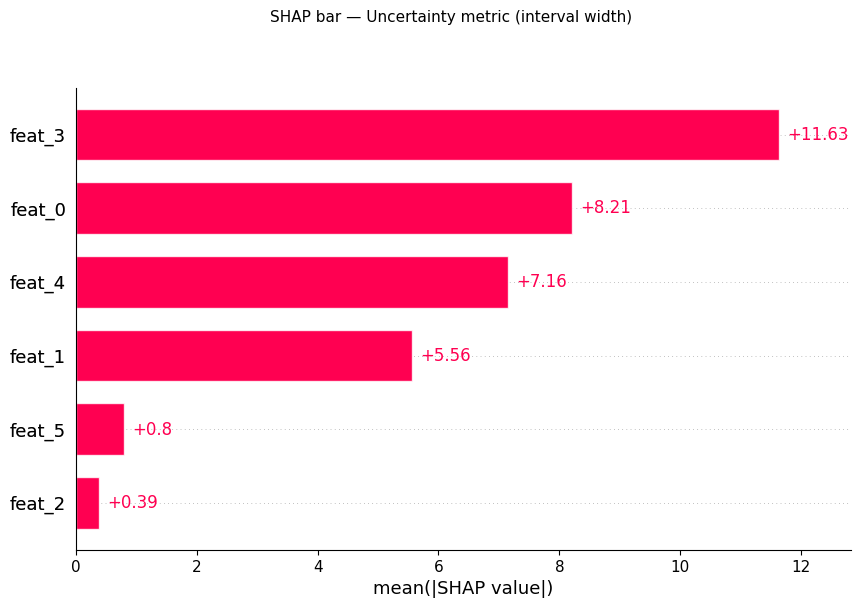

In [14]:
pipeline_cqr = UncertaintyExplanationPipeline(
    conformal_method="cqr",
    lower_model=GradientBoostingRegressor(loss="quantile", alpha=0.05, random_state=42),
    upper_model=GradientBoostingRegressor(loss="quantile", alpha=0.95, random_state=42),
    xai_method="shap",
)
pipeline_cqr.fit(X_train, y_train, X_calib, y_calib)
result_cqr = pipeline_cqr.explain(X_test.iloc[:50], show_plots=False)

covered_cqr = (result_cqr.lower <= y_test[:50]) & (y_test[:50] <= result_cqr.upper)
print(f"CQR Coverage @ 90 %: {covered_cqr.mean():.2f}")

figs_cqr = generate_shap_plots(
    result_cqr.explanation_values, X=X_test.iloc[:50], kinds=["bar"], show=False
)
figs_cqr["bar"]

---
## Part 2 — Classification

Conformal **prediction sets** for a multi-class classifier.
The set contains every class whose conformal p-value exceeds `1 − confidence`.

### 2.1 Data

4-class synthetic dataset with 7 features, 2 000 samples.

In [15]:
np.random.seed(0)

Xc_raw, yc = make_classification(
    n_samples=2000, n_features=7, n_informative=4,
    n_redundant=2, n_classes=4, random_state=0,
    weights=[0.3, 0.25, 0.25, 0.2],
)
feature_names_c = [
    "tenure_months", "monthly_charges", "total_charges", "support_tickets",
    "days_since_login", "n_products", "contract_length_months",
]
Xc = pd.DataFrame(Xc_raw, columns=feature_names_c)

Xc_train, Xc_temp, yc_train, yc_temp = train_test_split(Xc, yc, test_size=0.4, random_state=0)
Xc_calib, Xc_test, yc_calib, yc_test = train_test_split(Xc_temp, yc_temp, test_size=0.5, random_state=0)

print(f"Train: {Xc_train.shape} | Calib: {Xc_calib.shape} | Test: {Xc_test.shape}")
print(f"Classes: {np.unique(yc)}")

Train: (1200, 7) | Calib: (400, 7) | Test: (400, 7)
Classes: [0 1 2 3]


### 2.2 Quickstart (3 lines)

Set `task="classification"` — everything else is automatic.

In [16]:
quick_c = UncertaintyExplanationPipeline(
    model=RandomForestClassifier(random_state=0),
    task="classification",
)
quick_c.fit(Xc_train, yc_train)
result_qc = quick_c.explain(Xc_test.iloc[:30], show_plots=False)

covered_qc = result_qc.prediction_set[np.arange(30), yc_test[:30]]
print(f"Coverage @ 90 %: {covered_qc.mean():.2f}  (target ≥ 0.90)")
print(f"Mean set size:   {result_qc.set_size.mean():.2f} / {result_qc.classes.shape[0]} classes")

Coverage @ 90 %: 0.97  (target ≥ 0.90)
Mean set size:   1.73 / 4 classes


### 2.3 SHAP Explanations

For classification, SHAP explains `uncertainty_metric`:

| Value | Meaning |
|---|---|
| `"set_size"` | size of the prediction set *(default)* |
| `"credibility"` | max p-value across classes |
| `"confidence"` | second-largest p-value (margin to next class) |

**`conformal_method` options** (classification):

| Value | Description |
|---|---|
| `"standard"` | single calibration pool *(default)* |
| `"class_cond"` | separate calibration per class |
| `"mondrian"` | same as `class_cond` for classifiers |

In [17]:
pipeline_c = UncertaintyExplanationPipeline(
    model=RandomForestClassifier(n_estimators=100, random_state=0),
    task="classification",
    confidence=0.9,
    conformal_method="class_cond",
    xai_method="shap",
    uncertainty_metric="set_size",
)
pipeline_c.fit(Xc_train, yc_train, Xc_calib, yc_calib)
result_c = pipeline_c.explain(Xc_test.iloc[:80], show_plots=False)

covered_c = result_c.prediction_set[np.arange(80), yc_test[:80]]
print(f"Coverage: {covered_c.mean():.2f}")
print(f"Mean set size: {result_c.set_size.mean():.2f}")
print(f"SHAP shape: {result_c.explanation_values.values.shape}")

ExactExplainer explainer: 81it [01:23,  1.17s/it]                        

Coverage: 0.96
Mean set size: 1.69
SHAP shape: (80, 7)


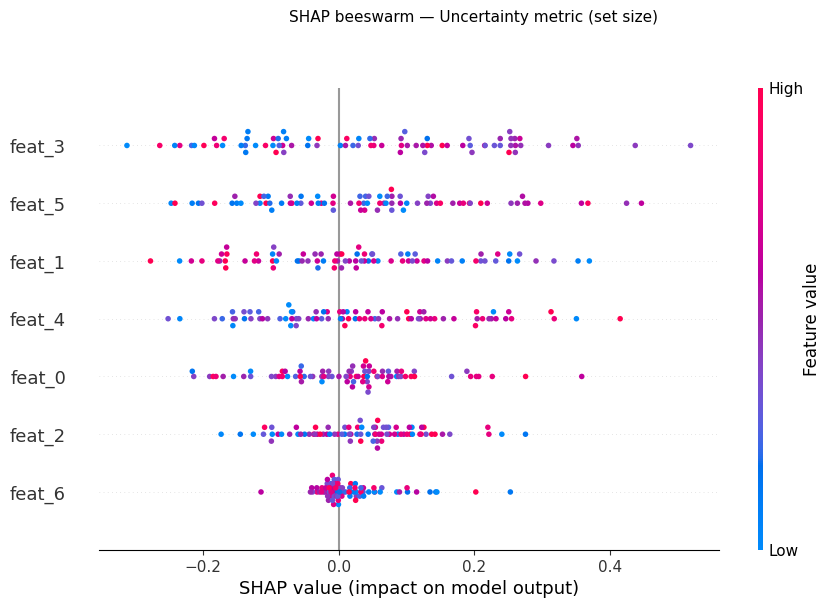

In [18]:
figs_c = generate_shap_plots(
    result_c.explanation_values,
    X=Xc_test.iloc[:80],
    kinds=["beeswarm", "bar"],
    show=False,
)
figs_c["beeswarm"]

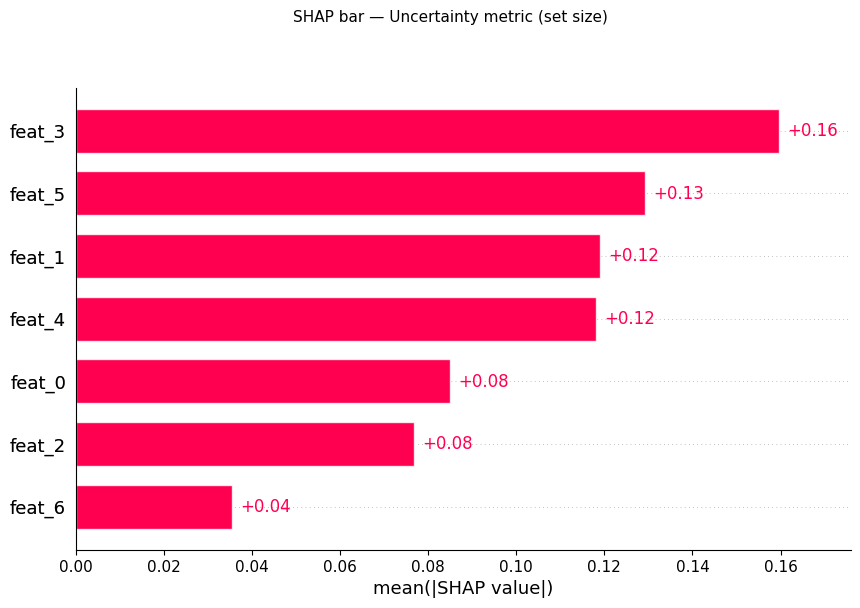

In [19]:
figs_c["bar"]

### 2.4 PDP + ICE Explanations (Classification)

PDP explains `uncertainty_metric` (e.g. `set_size`) for classification the same way as regression.
Rendered with sklearn's native **`PartialDependenceDisplay`**.


In [20]:
pipeline_c_pdp = UncertaintyExplanationPipeline(
    model=RandomForestClassifier(n_estimators=100, random_state=0),
    task="classification",
    confidence=0.9,
    conformal_method="class_cond",
    xai_method="pdp",
    uncertainty_metric="set_size",
)
pipeline_c_pdp.fit(Xc_train, yc_train, Xc_calib, yc_calib)
result_c_pdp = pipeline_c_pdp.explain(Xc_test.iloc[:100], kind="both", show_plots=False)


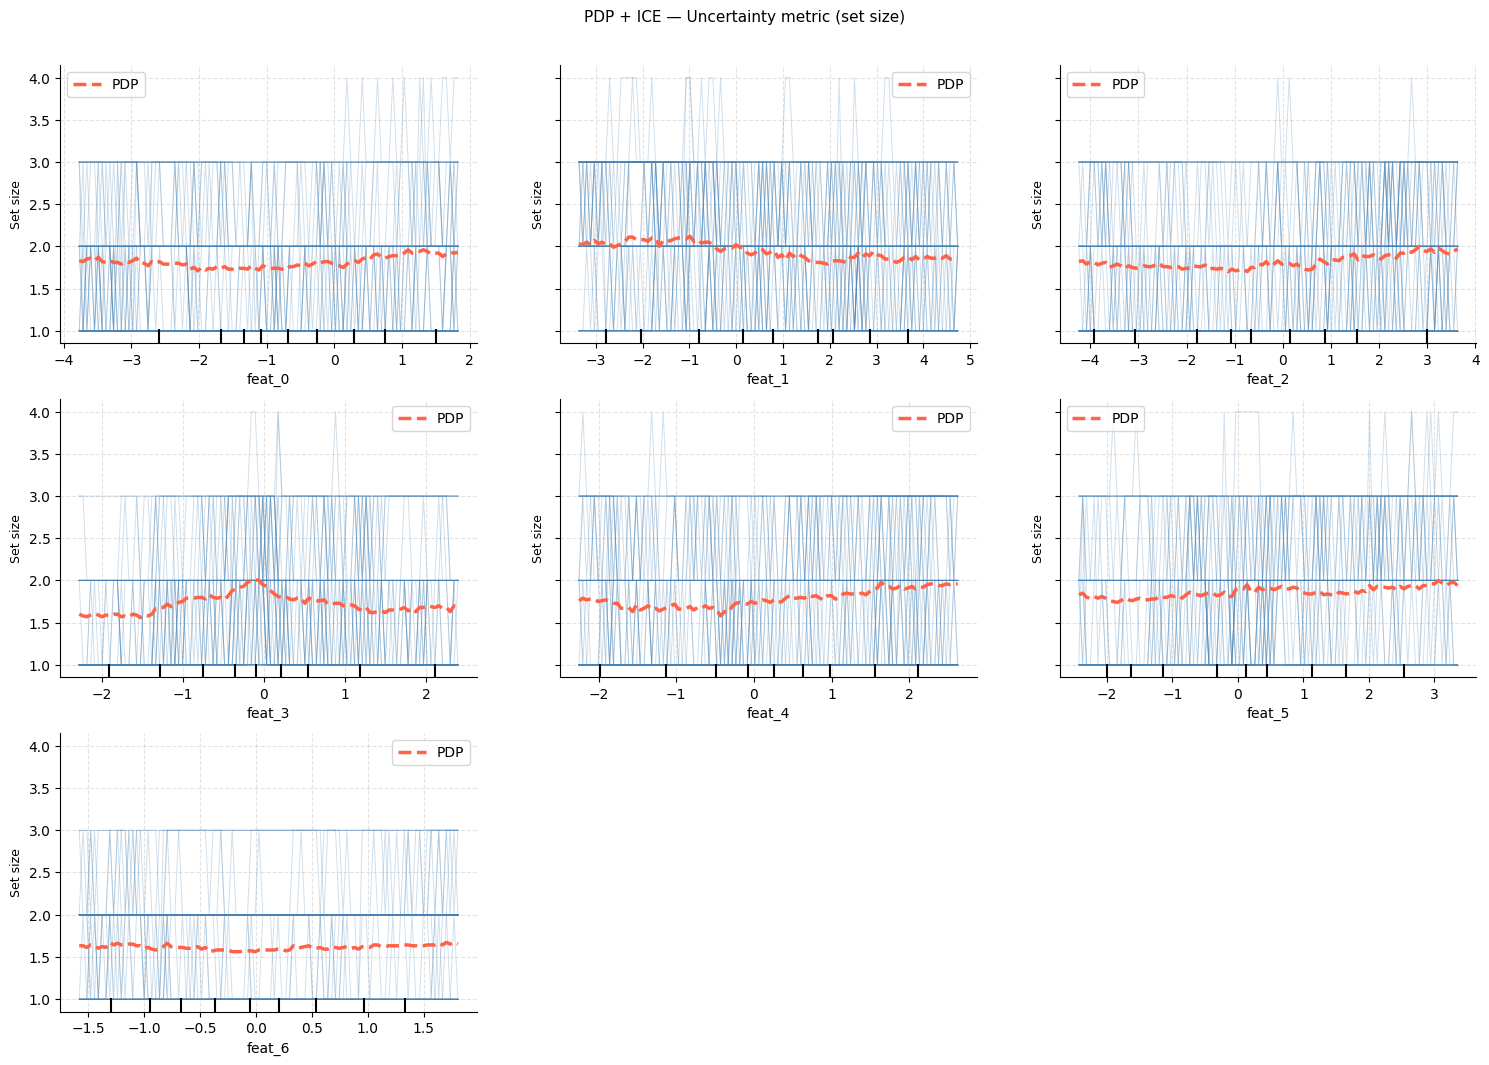

In [21]:
figs_c_pdp = generate_pdp_plots(result_c_pdp.explanation_values, kinds=["pdp_ice"], show=False)
figs_c_pdp["pdp_ice"]


### 2.5 LIME Explanations (Classification)

LIME local explanation for a single test sample, using LIME's native **`as_pyplot_figure()`**.
Shows the feature value ranges that most influenced the predicted set size.


In [22]:
pipeline_c_lime = UncertaintyExplanationPipeline(
    model=RandomForestClassifier(n_estimators=100, random_state=0),
    task="classification",
    confidence=0.9,
    conformal_method="class_cond",
    xai_method="lime",
    uncertainty_metric="set_size",
    n_lime_samples=300,
)
pipeline_c_lime.fit(Xc_train, yc_train, Xc_calib, yc_calib)
result_c_lime = pipeline_c_lime.explain(Xc_test.iloc[:5], show_plots=False)


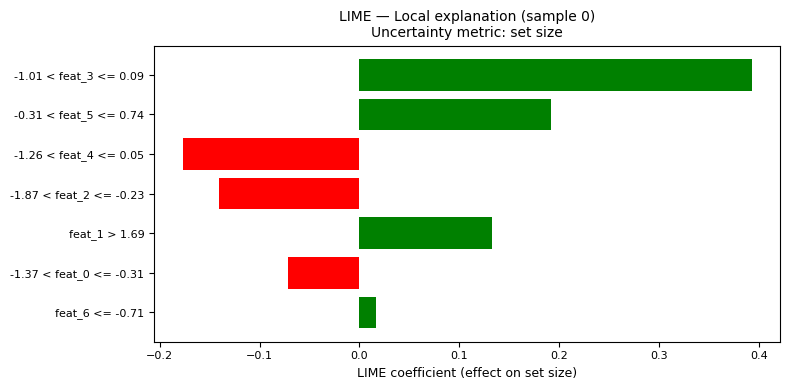

In [23]:
figs_c_lime = generate_lime_plots(
    result_c_lime.explanation_values, kinds=["local"], sample_index=0, show=False
)
figs_c_lime["local"]


### 2.6 Conformal Methods Comparison

Different conformal methods trade off coverage, set size, and class balance.


In [24]:
rows = []
for method in ["standard", "class_cond", "mondrian"]:
    p = UncertaintyExplanationPipeline(
        model=RandomForestClassifier(n_estimators=50, random_state=0),
        task="classification",
        confidence=0.9,
        conformal_method=method,
        xai_method="shap",
    )
    p.fit(Xc_train, yc_train, Xc_calib, yc_calib)
    r = p.explain(Xc_test.iloc[:100], show_plots=False)
    covered_m = r.prediction_set[np.arange(100), yc_test[:100]]
    rows.append({
        "conformal_method": method,
        "coverage": round(covered_m.mean(), 3),
        "mean_set_size": round(r.set_size.mean(), 2),
        "empty_sets": int((r.set_size == 0).sum()),
        "full_sets (all classes)": int((r.set_size == r.classes.shape[0]).sum()),
    })

pd.DataFrame(rows).set_index("conformal_method")

ExactExplainer explainer: 101it [00:27,  2.31it/s]                         
ExactExplainer explainer: 101it [01:38,  1.10s/it]                         
ExactExplainer explainer: 101it [00:28,  2.30it/s]                         


,coverage,mean_set_size,empty_sets,full_sets (all classes)
conformal_method,,,,
standard,0.95,1.74,0,0
class_cond,0.94,1.63,0,0
mondrian,0.91,1.61,0,0
